# 온라인 쇼핑몰 매출 관계분석
- 국가통계포털 https://kosis.kr/search/search.do
- 온라인쇼핑몰 판매매체별/상품군별거래액 검색
- 합계는 제외, 시점은 월별로 정리(단, 2020년도부터는 전기전자통신은 분리가됨)

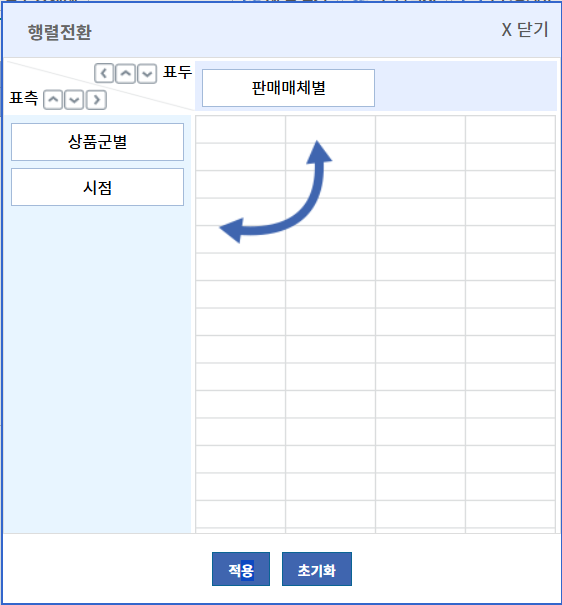

In [3]:
import pandas as pd
file_path = "./dataset/온라인쇼핑몰판매매체별상품군별거래액20260609.csv"
raw = pd.read_csv(file_path, encoding="EUC-KR")
raw.columns = ['category','year','internet','mobile']
raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020.01,332810,273459
1,컴퓨터 및 주변기기,2020.02,358997,315829
2,컴퓨터 및 주변기기,2020.03,401374,357883
3,컴퓨터 및 주변기기,2020.04,388215,331746
4,컴퓨터 및 주변기기,2020.05,323924,290304
...,...,...,...,...
1743,기타,2025.12,83267,181591
1744,기타,2026.01,69691,188568
1745,기타,2026.02,69460,168825
1746,기타,2026.03 p),86497,201182


In [9]:
# p라는 문자를 제거하는 방법
# 방법1
# raw['year'] = raw['year'].str.replace(" p)","")
# 방법2
raw['year'] = raw['year'].str.rstrip(' p)')
# 방법3
# raw['year'] = raw['year'].map(lambda x : x.rstrip(' p)'))
raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020.01,332810,273459
1,컴퓨터 및 주변기기,2020.02,358997,315829
2,컴퓨터 및 주변기기,2020.03,401374,357883
3,컴퓨터 및 주변기기,2020.04,388215,331746
4,컴퓨터 및 주변기기,2020.05,323924,290304
...,...,...,...,...
1743,기타,2025.12,83267,181591
1744,기타,2026.01,69691,188568
1745,기타,2026.02,69460,168825
1746,기타,2026.03,86497,201182


In [13]:
raw['year'] = pd.to_datetime(raw['year'], format="%Y.%m")
raw["category"].unique()

<ArrowStringArray>
[ '컴퓨터 및 주변기기',  '가전·전자·통신기기',          '서적',       '사무·문구',          '의복',
          '신발',          '가방', '패션용품 및 액세서리',    '스포츠·레저용품',         '화장품',
     '아동·유아용품',       '음·식료품',       '농축수산물',        '생활용품', '자동차 및 자동차용품',
          '가구',        '애완용품',  '여행 및 교통서비스',  '문화 및 레저서비스',      '이쿠폰서비스',
       '음식서비스',       '기타서비스',          '기타']
Length: 23, dtype: str

In [18]:
mydata = raw.copy()
mydata2 = mydata[mydata["category"].isin(['컴퓨터 및 주변기기','자동차 및 자동차용품','서적','음식서비스','여행 및 교통서비스','문화 및 레저서비스','스포츠·레저용품'])]
mydata2.sample(10)

,category,year,internet,mobile
1350,여행 및 교통서비스,2024-11-01,708869,1929370
1376,문화 및 레저서비스,2020-09-01,12061,28739
53,컴퓨터 및 주변기기,2024-06-01,362861,316252
165,서적,2021-02-01,119527,100736
1138,자동차 및 자동차용품,2026-03-01,896317,205996
641,스포츠·레저용품,2022-10-01,167426,427432
664,스포츠·레저용품,2024-09-01,118301,337688
20,컴퓨터 및 주변기기,2021-09-01,361370,374921
25,컴퓨터 및 주변기기,2022-02-01,442616,501035
197,서적,2023-10-01,82886,85813


Text(0.2, 0.4, '한글')

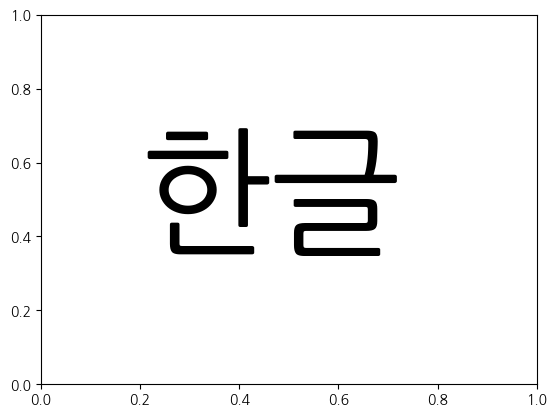

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

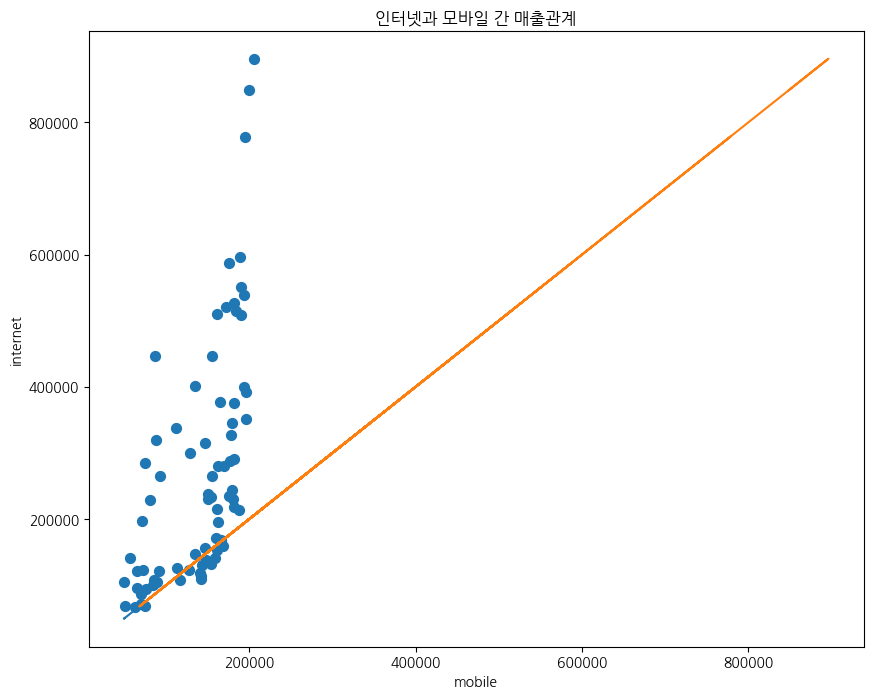

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))
prod = mydata[mydata['category'] == '자동차 및 자동차용품']
x = prod['mobile']
y = prod['internet']
ax.scatter(x,y, s=50)
ax.plot(x,x)
ax.plot(y,y)
ax.set_title('인터넷과 모바일 간 매출관계')
ax.set_xlabel('mobile')
ax.set_ylabel('internet')
plt.show()

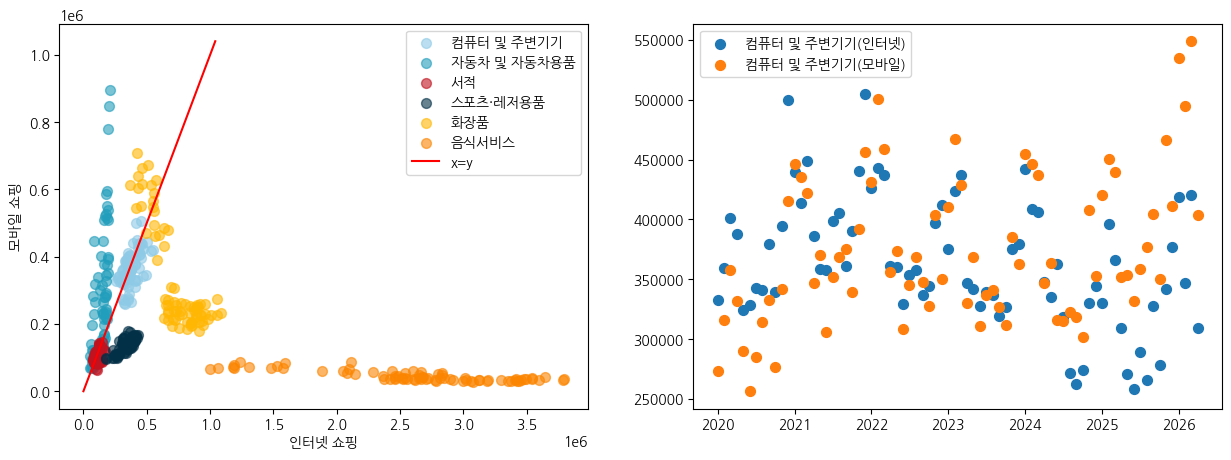

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

category = ['컴퓨터 및 주변기기','자동차 및 자동차용품','서적','스포츠·레저용품','화장품','음식서비스']
colors = {'컴퓨터 및 주변기기':'#8ecae6','자동차 및 자동차용품':'#219ebc','서적':'#c1121f','스포츠·레저용품':'#023047','화장품':'#ffb703','음식서비스':'#fb8500'}

# 색상반환함수
def color_by(category_name):
    return colors.get(category_name, 'black')  # 기본값은 블랙


fig , ax = plt.subplots(1,2,figsize=(15,5))
for c in category:
    prod = mydata[mydata['category'] == c]
    x = prod['mobile']
    y = prod['internet']
    ax[0].scatter(x,y, s = 50, color=color_by(c), label=c,alpha=0.6)

ax[0].set_xlabel("인터넷 쇼핑")
ax[0].set_ylabel("모바일 쇼핑")

xx = np.linspace(0, max(mydata2['internet']), 1000)
ax[0].plot(xx, xx, color='red', linestyle='-', label='x=y')
ax[0].legend()

# 두 번째 그래프: 특정 카테고리 하나만 선택
target_category = '컴퓨터 및 주변기기'
second = mydata[mydata['category'] == target_category]

tdata = second['year']
idata = second['internet']
mdata = second['mobile']

ax[1].scatter(tdata , idata, s = 50, label = target_category+'(인터넷)')
ax[1].scatter(tdata , mdata, s = 50, label = target_category+'(모바일)')
ax[1].legend()
plt.show()